In [1]:
from functools import reduce

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import pickle

In [2]:
# with open(r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\val_preds\correct.bin', 'rb') as f:
#     ans_df = pickle.load(file=f)
#     ans_df = ans_df[ans_df['task'] != 'SIQA']

# ans_df.head()

In [3]:
# preds_path_ls = [
#     ('Raw',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\val_preds\Raw-CR.bin'),
#     ('LoRA',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\val_preds\LoRA-cfg18-CR.bin'),
#     ('LoRA 1b',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\val_preds\LoRA_1b-cfg1-CR.bin'),
#     ('DoRA',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\val_preds\DoRA-cfg18-CR.bin'),
#     ('VeRA',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\val_preds\VeRA-cfg1-CR.bin'),
#     ('GSOFT',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\val_preds\GSOFT-cfg3-CR.bin'),
# ]

preds_path_ls = [
    ('Raw_1b',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\val_preds\Raw_1b_CR.bin'),
    ('LoRA_1b-CR',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\val_preds\LoRA_1b-cfg1-CR_CR.bin'),
]

for st in range(2_000, 16_000+1, 2_000):
    preds_path_ls.append(
        (f'LoRA_1b-code st-{st}', rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\val_preds\LoRA_1b-cfg1-st{st}_CR.bin')
    )

In [4]:
preds_dfs = []

for run_name, preds_path in preds_path_ls:
    with open(preds_path, 'rb') as f:
        preds_df: pd.DataFrame = pickle.load(file=f)

        # preds_df = preds_df[preds_df['task'] != 'SIQA']
        preds_df.insert(loc=len(preds_df.columns), column='run_name', value=run_name)

        # if run_name == 'GSOFT':
        #     preds_df = pd.merge(
        #         left=ans_df,
        #         right=preds_df,
        #         how='inner',
        #         on=['text', 'text_wa_answer', 'task'],
        #         validate='1:1'
        #     )

        preds_dfs.append(preds_df)

In [5]:
preds_df = pd.concat(preds_dfs)

preds_df.head()

,text,text_wa_answer,correct_answer,task,model_pred,run_name
0,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,False,BoolQ,{'generated_text': ': False'},Raw_1b
1,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,True,BoolQ,{'generated_text': ': False'},Raw_1b
2,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,True,BoolQ,{'generated_text': ': False'},Raw_1b
3,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,True,BoolQ,{'generated_text': ': TRUE'},Raw_1b
4,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,True,BoolQ,{'generated_text': ': True'},Raw_1b


In [6]:
preds_df[['task', 'correct_answer']].value_counts().sort_index()

task        correct_answer
ARC-C       1                    20
            2                    10
            4                    10
            A                   620
            B                   720
            C                   780
            D                   820
            E                    10
ARC-E       1                    60
            2                    70
            3                    50
            4                    30
            A                  1520
            B                  1450
            C                  1370
            D                  1150
BoolQ       False             12370
            True              20330
OBQA        A                  1260
            B                  1380
            C                  1100
            D                  1260
PIQA        Solution1          9100
            Solution2          9280
SIQA        A                  6430
            B                  6540
            C                  6570
h

In [7]:
sorted(list(preds_df['correct_answer'].unique()))

['1',
 '2',
 '3',
 '4',
 'A',
 'B',
 'C',
 'D',
 'E',
 'Ending0',
 'Ending1',
 'Ending2',
 'Ending3',
 'False',
 'Option1',
 'Option2',
 'Solution1',
 'Solution2',
 'True']

In [8]:
preds_df['run_name'].value_counts()

run_name
Raw_1b                   19740
LoRA_1b-CR               19740
LoRA_1b-code st-2000     19740
LoRA_1b-code st-4000     19740
LoRA_1b-code st-6000     19740
LoRA_1b-code st-8000     19740
LoRA_1b-code st-10000    19740
LoRA_1b-code st-12000    19740
LoRA_1b-code st-14000    19740
LoRA_1b-code st-16000    19740
Name: count, dtype: int64

In [9]:
tasks = preds_df.task.unique()

tasks

array(['BoolQ', 'PIQA', 'SIQA', 'hellaswag', 'winogrande', 'ARC-E',
       'ARC-C', 'OBQA'], dtype=object)

In [10]:
import string
import re

punct_trans = str.maketrans(dict.fromkeys(string.punctuation))

def BoolQ_process(pred):
    pred = pred['generated_text'].strip()
    pred = pred.translate(punct_trans)
    pred = pred.split()[0].strip()

    return pred

def SIQA_process(pred):
    pred = pred['generated_text'].strip()
    pred = pred.translate(punct_trans)
    pred = pred.split()[0].strip()

    return pred

PIQA_pattern = re.compile('Solution[1,2]')
def PIQA_process(pred):
    pred = pred['generated_text'].strip()
    pred = pred.translate(punct_trans)
    pred = pred.split()[0].strip() if pred else ''
    pred = re.match(PIQA_pattern, pred)
    pred = pred.group(0) if pred else 'None'

    return pred

hellaswag_pattern = re.compile('(Ending)?[0,1,2,3]')
def hellaswag_process(pred):
    pred = pred['generated_text']
    pred_0 = pred

    pred = pred.translate(punct_trans).strip()
    pred = pred.split()[0] if pred else ''
    pred = re.match(hellaswag_pattern, pred)
    if pred:
        pred = pred.group(0)
        pred = f'Ending{pred[-1]}'
    else:
        pred = pred_0

    return pred

winogrande_pattern = re.compile('Option[1,2]')
def winogrande_process(pred):
    pred = pred['generated_text']
    pred_0 = pred

    pred = pred.translate(punct_trans).strip()
    pred = pred.split()[0] if pred else ''
    pred = re.match(winogrande_pattern, pred)
    if pred:
        pred = pred.group(0)
        pred = f'Option{pred[-1]}'
    else:
        pred = pred_0

    return pred

def ARC_process(pred):
    pred = pred['generated_text'].strip()
    pred = pred.translate(punct_trans)
    pred = pred.split()[0].strip()

    return pred

def OBQA_process(pred):
    pred = pred['generated_text'].strip()
    pred = pred.translate(punct_trans)
    pred = pred.split()[0].strip()

    return pred

In [11]:
preds_dfs[0][preds_dfs[0]['task'] == 'SIQA']['model_pred'].apply(SIQA_process)

5108    B
5109    A
5110    A
5111    A
5112    A
       ..
7057    C
7058    B
7059    C
7060    B
7061    B
Name: model_pred, Length: 1954, dtype: object

In [12]:
preds_dfs[0][preds_dfs[0]['task'] == 'SIQA']['correct_answer'][5108]

'C'

In [13]:
task_postprocessors = {
    'BoolQ': BoolQ_process,
    'PIQA': PIQA_process,
    'SIQA': SIQA_process,
    'hellaswag': hellaswag_process,
    'winogrande': winogrande_process,
    'ARC-E': ARC_process,
    'ARC-C': ARC_process,
    'OBQA': OBQA_process
}

for task, processor in task_postprocessors.items():
    preds_df.loc[preds_df['task'] == task, 'model_pred'] = preds_df.loc[preds_df['task'] == task, 'model_pred'].apply(processor)

preds_df.head()

,text,text_wa_answer,correct_answer,task,model_pred,run_name
0,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,False,BoolQ,False,Raw_1b
1,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,True,BoolQ,False,Raw_1b
2,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,True,BoolQ,False,Raw_1b
3,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,True,BoolQ,TRUE,Raw_1b
4,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,True,BoolQ,True,Raw_1b


In [14]:
preds_df.loc[:, 'is_correct'] = (preds_df.loc[:, 'correct_answer'] == preds_df.loc[:, 'model_pred'])

preds_df.head()

,text,text_wa_answer,correct_answer,task,model_pred,run_name,is_correct
0,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,False,BoolQ,False,Raw_1b,True
1,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,True,BoolQ,False,Raw_1b,False
2,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,True,BoolQ,False,Raw_1b,False
3,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,True,BoolQ,TRUE,Raw_1b,False
4,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,True,BoolQ,True,Raw_1b,True


In [15]:
accuracy = preds_df[['run_name', 'task', 'is_correct']].groupby(by=['run_name', 'task'], as_index=False)['is_correct'].mean()

accuracy

,run_name,task,is_correct
0,LoRA_1b-CR,ARC-C,0.585284
1,LoRA_1b-CR,ARC-E,0.735088
2,LoRA_1b-CR,BoolQ,0.648012
3,LoRA_1b-CR,OBQA,0.694000
4,LoRA_1b-CR,PIQA,0.763874
...,...,...,...
75,Raw_1b,OBQA,0.428000
76,Raw_1b,PIQA,0.553863
77,Raw_1b,SIQA,0.503071
78,Raw_1b,hellaswag,0.258116


In [16]:
accuracy[accuracy['run_name'] == 'GSOFT']

,run_name,task,is_correct


In [20]:
total_res = accuracy[['run_name', 'is_correct']].groupby(by=['run_name'], as_index=False).mean()

total_res

,run_name,is_correct
0,LoRA_1b-CR,0.688823
1,LoRA_1b-code st-10000,0.489730
2,LoRA_1b-code st-12000,0.489046
3,LoRA_1b-code st-14000,0.477418
4,LoRA_1b-code st-16000,0.479745
5,LoRA_1b-code st-2000,0.594282
6,LoRA_1b-code st-4000,0.522557
7,LoRA_1b-code st-6000,0.507180
8,LoRA_1b-code st-8000,0.521440
9,Raw_1b,0.460116


In [29]:
total_res[total_res['run_name'] == 'Raw_1b'].is_correct.iloc[-1]

0.4601163345574698

Text(0, 0.5, 'CR mean accuracy')

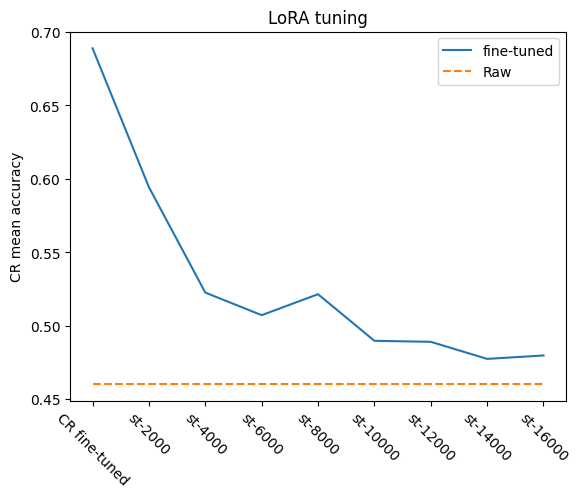

In [38]:
scores = [total_res[total_res['run_name'] == 'LoRA_1b-CR'].is_correct.iloc[-1]]
scores += [
    total_res[total_res['run_name'] == f'LoRA_1b-code st-{st}'].is_correct.iloc[-1]
    for st in range(2000, 16000+1,2000)
]

sns.lineplot(
    x=range(0, 16000+1, 2000),
    y=scores,
    label='fine-tuned'
)

sns.lineplot(
    x=[0, 16_000],
    y=[total_res[total_res['run_name'] == 'Raw_1b'].is_correct.iloc[-1]] * 2,
    linestyle='--',
    label='Raw'
)

plt.xticks(
    range(0, 16000+1,2000),
    labels=['CR fine-tuned'] + [f'st-{st}' for st in range(2000, 16000+1,2000)],
    rotation=-45
)

plt.title('LoRA tuning')
plt.ylabel('CR mean accuracy')